In [2]:
%pip install scikit-learn scipy

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [5]:
data_dir = Path.cwd()
csv_path = data_dir / "/content/Online Retail.xlsx"
df = pd.read_excel(csv_path)
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


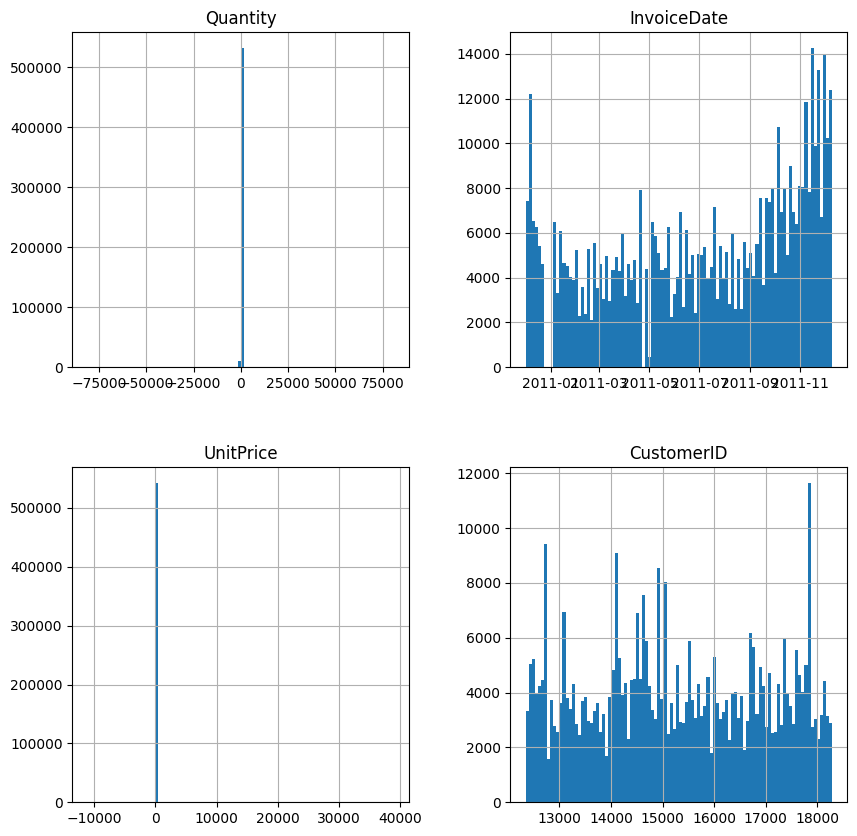

In [7]:
df.hist(figsize=(10,10),bins=100)
plt.show()

In [8]:
df2 = df.drop(["CustomerID"],axis=1)
df2

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,United Kingdom
...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,France


In [9]:
outlier1 = df2["Quantity"] == df2["Quantity"].max()
outlier2 = df2["UnitPrice"] == df2["UnitPrice"].max()
df2 = df2.loc[~outlier1 & ~outlier2,:]
df2


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,United Kingdom
...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,France


In [10]:
df2["TotalPrice"]=df2["Quantity"] * df2["UnitPrice"]
df2

/tmp/ipykernel_7331/4038972198.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["TotalPrice"]=df2["Quantity"] * df2["UnitPrice"]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,United Kingdom,20.34
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,France,16.60


In [12]:
# num_cols = df2.select_dtypes(include='number').columns.tolist()
# num_cols
cat_cols = df2.select_dtypes(include="object").columns.tolist()
cat_cols

['InvoiceNo', 'StockCode', 'Description', 'Country']

In [13]:
num_cols=["Quantity","UnitPrice","TotalPrice"]
cat_cols=["Country"]

In [14]:
df3 = df2.sample(frac=0.2, random_state=42).reset_index(drop=True)
df3

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country,TotalPrice
0,545188,48184,DOORMAT ENGLISH ROSE,1,2011-02-28 15:19:00,7.95,United Kingdom,7.95
1,560557,84711B,PINK OVAL SHAPE TRINKET BOX,3,2011-07-19 13:05:00,9.95,United Kingdom,29.85
2,565150,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2011-09-01 14:26:00,1.06,United Kingdom,25.44
3,537624,21064,BOOM BOX SPEAKER BOYS,1,2010-12-07 14:41:00,5.95,United Kingdom,5.95
4,579196,22845,VINTAGE CREAM CAT FOOD CONTAINER,1,2011-11-28 15:54:00,12.46,United Kingdom,12.46
...,...,...,...,...,...,...,...,...
108376,547786,20674,GREEN POLKADOT BOWL,1,2011-03-25 11:44:00,1.25,United Kingdom,1.25
108377,541604,51014L,"FEATHER PEN,LIGHT PINK",24,2011-01-19 17:23:00,0.85,United Kingdom,20.40
108378,569834,84946,ANTIQUE SILVER T-LIGHT GLASS,12,2011-10-06 13:00:00,1.25,United Kingdom,15.00
108379,560269,21174,POTTERING IN THE SHED METAL SIGN,12,2011-07-17 14:32:00,2.08,United Kingdom,24.96


In [15]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

num_cols=["Quantity","UnitPrice","TotalPrice"]
cat_cols=["Country"]

num_pipeline = Pipeline(steps=[
    ('imputing', SimpleImputer(strategy='median')),
    ('scaling', StandardScaler())
])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])



preprocessing = ColumnTransformer([
    ("NUM", num_pipeline, num_cols),
    ("CAT", cat_pipeline, cat_cols),
])

df_arr = preprocessing.fit_transform(df3)
df_tr = pd.DataFrame(df_arr, columns=preprocessing.get_feature_names_out())
df_tr.head()

,NUM__Quantity,NUM__UnitPrice,NUM__TotalPrice,CAT__Country_Australia,CAT__Country_Austria,CAT__Country_Bahrain,CAT__Country_Belgium,CAT__Country_Brazil,CAT__Country_Canada,CAT__Country_Channel Islands,...,CAT__Country_RSA,CAT__Country_Saudi Arabia,CAT__Country_Singapore,CAT__Country_Spain,CAT__Country_Sweden,CAT__Country_Switzerland,CAT__Country_USA,CAT__Country_United Arab Emirates,CAT__Country_United Kingdom,CAT__Country_Unspecified
0,-0.040415,0.043666,-0.043044,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.031688,0.069687,0.042948,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.059941,-0.045974,0.025631,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.040415,0.017646,-0.050897,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.040415,0.102342,-0.025335,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


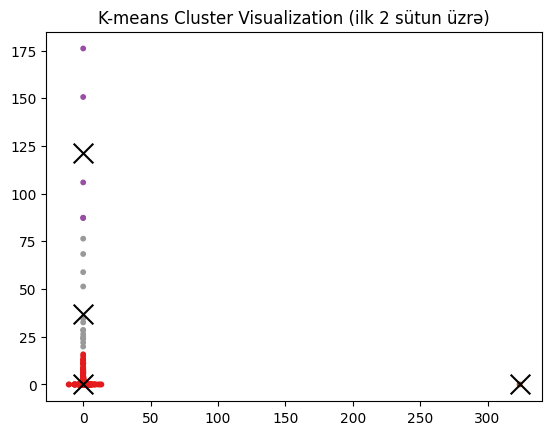

In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(df_tr)
df_tr['Cluster'] = kmeans.labels_
plt.scatter(df_tr.iloc[:, 0], df_tr.iloc[:, 1], c=df_tr['Cluster'], cmap='Set1', s=10)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='black', marker='x')
plt.title("K-means Cluster Visualization (ilk 2 sütun üzrə)")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


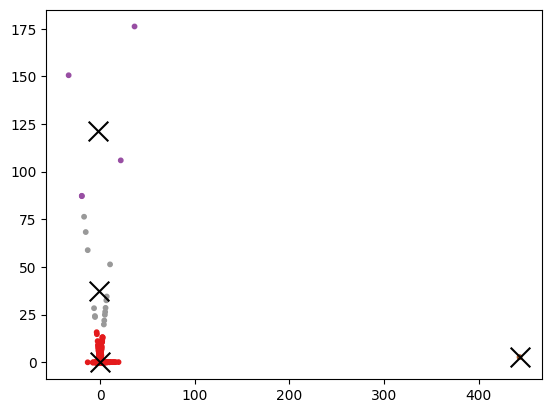

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_tr.drop(columns=['Cluster']))

plt.scatter(df_pca[:, 0], df_pca[:, 1], c=df_tr['Cluster'], cmap='Set1', s=10)
plt.scatter(pca.transform(kmeans.cluster_centers_)[:, 0], pca.transform(kmeans.cluster_centers_)[:, 1], s=200, c='black', marker='x')
plt.show()

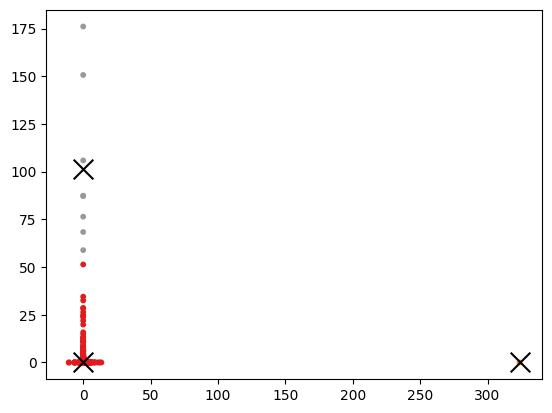

In [18]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)
kmeans.fit(df_tr)

plt.scatter(df_tr.iloc[:, 0], df_tr.iloc[:, 1], s=10, c=kmeans.labels_, cmap="Set1")
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, marker="x", color="black")
plt.show()

In [21]:
from sklearn.metrics import silhouette_score
score = silhouette_score(df_tr, kmeans.fit_predict(df_tr))
score

np.float64(0.9963902920697036)